In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [2]:
bc=load_breast_cancer()

In [ ]:
print(bc.DESCR)

# Dataset info

In [36]:
print(bc.keys())
print(bc.target[0])
print(bc.target.shape)
print(bc.data[500])
print(bc.data.shape)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
0
(569,)
[1.504e+01 1.674e+01 9.873e+01 6.894e+02 9.883e-02 1.364e-01 7.721e-02
 6.142e-02 1.668e-01 6.869e-02 3.720e-01 8.423e-01 2.304e+00 3.484e+01
 4.123e-03 1.819e-02 1.996e-02 1.004e-02 1.055e-02 3.237e-03 1.676e+01
 2.043e+01 1.097e+02 8.569e+02 1.135e-01 2.176e-01 1.856e-01 1.018e-01
 2.177e-01 8.549e-02]
(569, 30)


# Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(bc.data,bc.target,test_size=0.2)
# x=bc.data,y=bc.target

In [4]:
print(f"x_train={x_train.shape}  \n y_train={y_train.shape}\n x_test={x_test.shape}")

x_train=(455, 30)  
 y_train=(455,)
 x_test=(114, 30)


In [5]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler(feature_range=(0,1)) #convert all data between 0,1

x_train=scalar.fit_transform(x_train)
x_test=scalar.fit_transform(x_test)

# Classification

In [6]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix

def calculate_metrics(y_train,y_test,y_pred_train,y_pred_test): #fuction for calculation the metrics
    acc_train=accuracy_score(y_true=y_train , y_pred=y_pred_train)
    acc_test=accuracy_score(y_true=y_test, y_pred=y_pred_test)
    
    r=recall_score(y_true=y_test, y_pred=y_pred_test)
    p=precision_score(y_true=y_test, y_pred=y_pred_test)
    
    print(f"acc train={acc_train} \n acc_test={acc_test} \n recall={r} \n precision={p}")
    return acc_train,acc_test,r,p

# 1.Naive bays

In [18]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [19]:
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [20]:
acc_train_gnb,acc_test_gnb,r_gnb,p_gnb=calculate_metrics(y_train,y_test,y_pred_train,y_pred_test)

acc train=0.9406593406593406 
 acc_test=0.7280701754385965 
 recall=0.5866666666666667 
 precision=1.0


# 2.KNN

In [7]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=8, algorithm="kd_tree" , leaf_size=28)

model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

acc_train_knn,acc_test_knn,r_knn,p_knn=calculate_metrics(y_train,y_test,y_pred_train,y_pred_test)

acc train=0.9714285714285714 
 acc_test=0.9122807017543859 
 recall=0.88 
 precision=0.9850746268656716


# 3.Decision Tree

In [8]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=128, min_samples_split=4, criterion='entropy')

model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

acc_train_dt,acc_test_dt,r_dt,p_dt=calculate_metrics(y_train,y_test,y_pred_train,y_pred_test)

acc train=0.9978021978021978 
 acc_test=0.6140350877192983 
 recall=0.41333333333333333 
 precision=1.0


# 4.Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=500,max_depth=64,min_samples_split=8)

model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

acc_train_rf,acc_test_rf,r_rf,p_rf=calculate_metrics(y_train,y_test,y_pred_train,y_pred_test)

acc train=0.9934065934065934 
 acc_test=0.8157894736842105 
 recall=0.72 
 precision=1.0


# 5.SVM

In [10]:
from sklearn.svm import SVC
model=SVC(kernel="poly")

model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

acc_train_svm,acc_test_svm,r_svm,p_svm=calculate_metrics(y_train,y_test,y_pred_train,y_pred_test)

acc train=0.9846153846153847 
 acc_test=0.868421052631579 
 recall=0.8 
 precision=1.0


# 6.Logistic Regression:

In [11]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

acc_train_lr,acc_test_lr,r_lr,p_lr=calculate_metrics(y_train,y_test,y_pred_train,y_pred_test)

acc train=0.967032967032967 
 acc_test=0.9035087719298246 
 recall=0.8533333333333334 
 precision=1.0


# 7.ANN

In [15]:
from sklearn.neural_network import MLPClassifier
model=MLPClassifier(hidden_layer_sizes=256,activation="relu",solver="adam",batch_size=64)

model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

acc_train_ann,acc_test_ann,r_ann,p_ann=calculate_metrics(y_train,y_test,y_pred_train,y_pred_test)

acc train=0.9846153846153847 
 acc_test=0.6929824561403509 
 recall=0.5333333333333333 
 precision=1.0


c:\Users\razie\Documents\Python_practice\learning_venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# Comparison

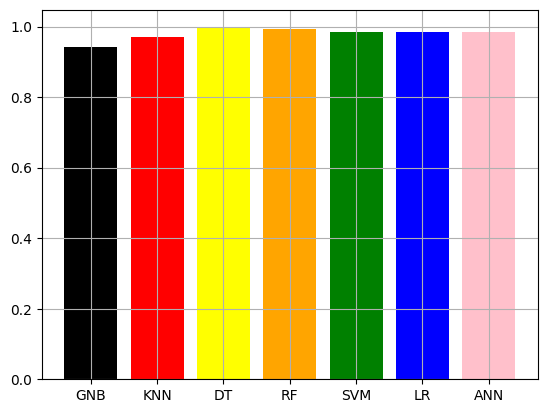

In [22]:
import matplotlib.pyplot as plt
acc_train=[acc_train_gnb,acc_train_knn,acc_train_dt,acc_train_rf,acc_train_svm,acc_train_lr,acc_train_ann]
title=["GNB","KNN","DT","RF","SVM","LR","ANN"]
colors=["black","red","yellow","orange","green","blue","pink"]

plt.bar(title,acc_train, color=colors)
plt.grid()
plt.show()


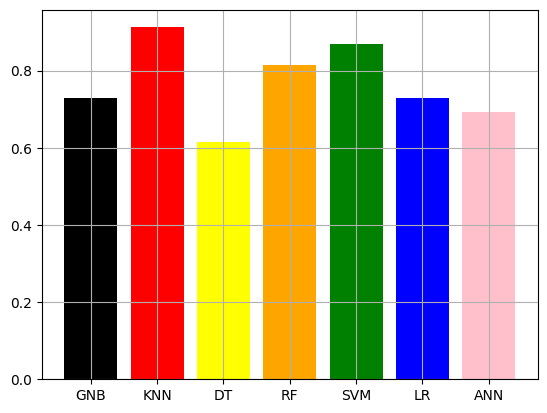

In [23]:
acc_test=[acc_test_gnb,acc_test_knn,acc_test_dt,acc_test_rf,acc_test_svm,acc_test_lr,acc_test_ann]
title=["GNB","KNN","DT","RF","SVM","LR","ANN"]
colors=["black","red","yellow","orange","green","blue","pink"]

plt.bar(title,acc_test, color=colors)
plt.grid()
plt.show()


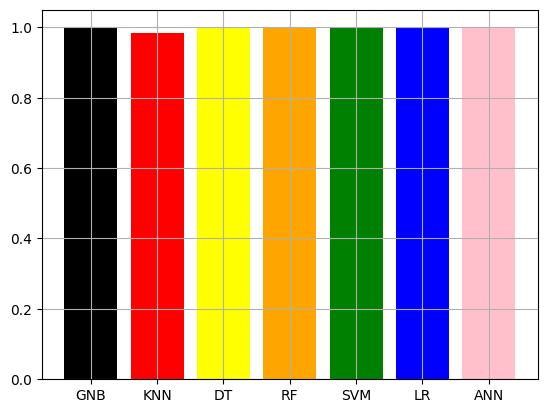

In [24]:
precision=[p_gnb,p_knn,p_dt,p_rf,p_svm,p_lr,p_ann]
title=["GNB","KNN","DT","RF","SVM","LR","ANN"]
colors=["black","red","yellow","orange","green","blue","pink"]

plt.bar(title,precision, color=colors)
plt.grid()
plt.show()


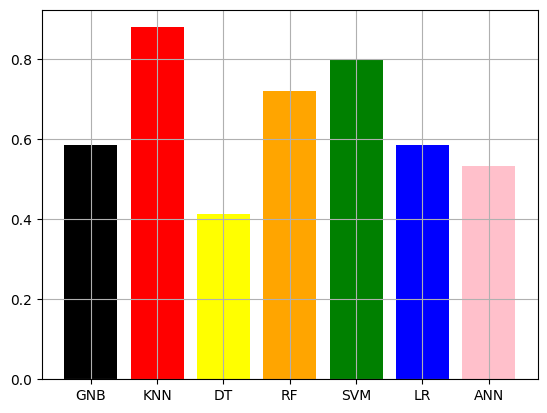

In [26]:
recall=[r_gnb,r_knn,r_dt,r_rf,r_svm,r_lr,r_ann]
title=["GNB","KNN","DT","RF","SVM","LR","ANN"]
colors=["black","red","yellow","orange","green","blue","pink"]

plt.bar(title,recall, color=colors)
plt.grid()
plt.show()
